In [ ]:
import pandas as pd
import numpy as np

#load datasets
orders_df = pd.read_csv('orders.csv')
items_df = pd.order_items = pd.read_csv('order_items.csv')

#convert 'placed_at' to Datetime on the ORDERS table 
orders_df['placed_at'] = pd.to_datetime(orders_df['placed_at'])

#the function to fix time
def assign_realistic_time(row):
    user = row['user_id']
    current_time = row['placed_at']
    
    if 41 <= user <= 60:
        new_hour = np.random.randint(6, 11)
    elif 21 <= user <= 40:
        new_hour = np.random.randint(11, 16)
    else:
        new_hour = np.random.randint(16, 21)
        
    return current_time.replace(hour=new_hour, minute=np.random.randint(0, 60))

#apply the fix to the unique orders
orders_df['placed_at'] = orders_df.apply(assign_realistic_time, axis=1)

#merge them
df = pd.merge(items_df, orders_df, on='order_id')

#check if it works 
print("Fixed Timestamps (Items in the same order now have the exact same time):")
df[['order_id', 'user_id', 'item_id', 'placed_at']].head(10)

Fixed Timestamps (Items in the same order now have the exact same time):


,order_id,user_id,item_id,placed_at
0,1,39,7,2025-02-18 12:48:00
1,1,39,16,2025-02-18 12:48:00
2,1,39,17,2025-02-18 12:48:00
3,2,41,49,2025-02-24 09:33:00
4,2,41,52,2025-02-24 09:33:00
5,2,41,53,2025-02-24 09:33:00
6,3,14,19,2025-02-26 19:27:00
7,4,39,26,2025-02-20 11:24:00
8,4,39,34,2025-02-20 11:24:00
9,4,39,35,2025-02-20 11:24:00


In [5]:
import json

#item-canteen map
unique_items = df.drop_duplicates(subset=['item_id'])
item_canteen_map = pd.Series(unique_items.cafeteria_id.values, index=unique_items.item_id).to_dict()

#save it as a json file
with open('item_canteen_map.json', 'w') as f:
    json.dump(item_canteen_map, f)
print("item_canteen_map.json saved successfully!")


#time-based rules map
def get_time_bucket(hour):
    if 6 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 16:
        return 'Lunch'
    else:
        return 'Evening'

df['time_bucket'] = df['placed_at'].dt.hour.apply(get_time_bucket)

#find the 10 most popular items in each bucket
time_rules = {}
for bucket in ['Morning', 'Lunch', 'Evening']:
    bucket_data = df[df['time_bucket'] == bucket]
    #count how many times each item was bought in this bucket, take the top 10, convert to list
    top_items = bucket_data['item_id'].value_counts().head(10).index.tolist()
    #convert numpy ints to standard python ints so it can be saved as json
    time_rules[bucket] = [int(i) for i in top_items]

#save it as a json file
with open('time_rules.json', 'w') as f:
    json.dump(time_rules, f)
print("time_rules.json saved successfully!\n")

#check fallback strategy
print("--- Cold Start Strategy Generated ---")
print(f"Morning Recommendations: {time_rules['Morning']}")
print(f"Lunch Recommendations: {time_rules['Lunch']}")
print(f"Evening Recommendations: {time_rules['Evening']}")

item_canteen_map.json saved successfully!
time_rules.json saved successfully!

--- Cold Start Strategy Generated ---
Morning Recommendations: [52, 53, 54, 32, 50, 33, 48, 12, 14, 47]
Lunch Recommendations: [34, 35, 16, 17, 54, 46, 42, 7, 28, 27]
Evening Recommendations: [54, 20, 37, 4, 41, 36, 19, 2, 23, 1]


In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

#user-item matrix
#group by user and item to get total purchase counts
purchase_counts = df.groupby(['user_id', 'item_id']).size().reset_index(name='purchase_count')

#pivot into a wide matrix and fill missing values with 0
user_item_matrix = purchase_counts.pivot(index='user_id', columns='item_id', values='purchase_count').fillna(0)

#normalize the data (per user)
#Min-Max scaling to bring all values between 0 and 1
#transpose (.T) so the scaler scales horizontally across users, then transpose back
scaler = MinMaxScaler()
normalized_matrix = pd.DataFrame(
    scaler.fit_transform(user_item_matrix.T).T,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)
print("User-Item matrix created and normalized.")

User-Item matrix created and normalized.


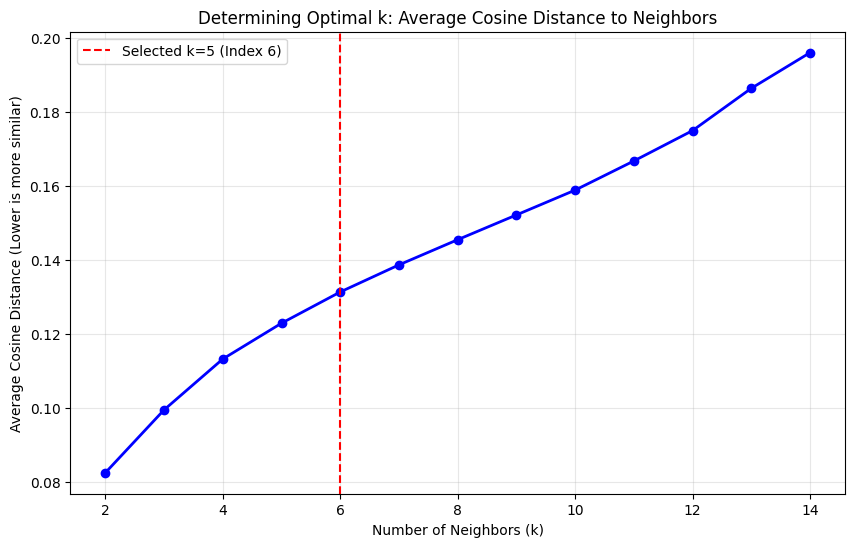

In [ ]:
#evaluation to determine optimal k
k_values = range(2, 15)
avg_distances = []

for k in k_values:
    #test different k values
    test_knn = NearestNeighbors(n_neighbors=k, metric='cosine', algorithm='brute')
    test_knn.fit(normalized_matrix)
    
    #calculate distances
    distances, _ = test_knn.kneighbors(normalized_matrix)
    
    #average the distance to the furthest neighbor in the cluster
    avg_distances.append(distances[:, -1].mean())

#plot the proof
plt.figure(figsize=(10, 6))
plt.plot(k_values, avg_distances, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Determining Optimal k: Average Cosine Distance to Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Cosine Distance (Lower is more similar)')
plt.axvline(x=6, color='red', linestyle='--', label='Selected k=5 (Index 6)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#from the graph we can see that the elbow point is around k=5, which supports the choice of n_neighbors=6 (including the user themselves).
#elbow point means that after this point, adding more neighbors does not significantly reduce the average distance, 
#indicating that those additional neighbors are less similar and may not contribute much to recommendation quality.

#train and save the knn model
#use cosine similarity to handle the massive amount of zeros (sparse data)
#set n_neighbors to 6 (1 for the user themselves + 5 actual neighbors)
knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(normalized_matrix)

#save the trained model and the normalized matrix structure
joblib.dump(knn_model, 'knn_model.pkl')
normalized_matrix.to_pickle('user_item_matrix.pkl')

print("Model (knn_model.pkl) and Matrix (user_item_matrix.pkl) saved successfully!\n")

Model (knn_model.pkl) and Matrix (user_item_matrix.pkl) saved successfully!

